# HDT 3: Inferencia, Naive Bayes y Regresión

**Ciencia de Datos, Sección A** · Asignada: jueves 20 de agosto · **Entrega: jueves 27 de agosto, 23:59**

**Nombre:** _Victor Saravia_
**Carné no.:** _20240060_

Completar las celdas marcadas con `# ¿Qué va aquí?`. Cada ejercicio incluye una verificación comentada: descomentar para comprobar el resultado. Antes de entregar: **Kernel → Restart & Run All** (un notebook que no corre de arriba a abajo pierde 0.5 pts).

AI: resolver sin AI. Si se usó para entender un concepto, anotarlo en la mini-bitácora del final.

## Setup

Dependencias: `pip install numpy pandas matplotlib seaborn scikit-learn`. Todo es determinista (semillas fijas y datasets estáticos): las verificaciones son exactas.

In [2]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

AZUL, ROJO, GRIS, LINEA = "#3A6EA5", "#B04A2E", "#75808E", "#E0E4EA"

def eje_limpio(ax):
    ax.grid(color=LINEA, lw=0.6, alpha=0.7)
    ax.spines[["top", "right"]].set_visible(False)

## Parte A · Inferencia y A/B testing (0.5 pt)

El experimento del botón, en grande: 50,000 visitantes por grupo. La tasa real del control es 10.0% y la de la variante 10.5%: un efecto **pequeño** con una muestra **enorme**. Ese contraste es el tema de la parte D.

### Ejercicio 1 (0.15): la diferencia y su intervalo

(a) La diferencia observada `obs` entre variante y control. (b) El error estándar de la diferencia: $\sqrt{s_a^2/n + s_b^2/n}$ con `var(ddof=1)`. (c) El intervalo del 95%: `obs` ± 1.96 × SE. ¿El intervalo incluye el cero?

In [4]:
rng = np.random.default_rng(9)
n_ab = 50_000
control = rng.binomial(1, 0.100, n_ab)
variante = rng.binomial(1, 0.105, n_ab)

obs = variante.mean() - control.mean()

se = np.sqrt(
    control.var(ddof=1) / n_ab +
    variante.var(ddof=1) / n_ab
)

limite_inferior = obs - 1.96 * se
limite_superior = obs + 1.96 * se

print("Diferencia observada entre variable y control:", obs)
print("Error estándar de la diferencia:", se)
print("Intervalo del 95%:", limite_inferior, limite_superior)
# imprimir el intervalo

# Verificación (descomentar):
assert round(obs, 5) == 0.00506
assert round(obs - 1.96 * se, 5) == 0.00132

Diferencia observada entre variable y control: 0.005059999999999995
Error estándar de la diferencia: 0.0019083155277267612
Intervalo del 95%: 0.0013197015656555432 0.008800298434344447


### Ejercicio 2 (0.20): test de permutación desde cero

Si el botón no importara, las etiquetas serían intercambiables. Completar la función: concatenar, revolver `reps` veces, partir en dos grupos del tamaño original, guardar la diferencia, y devolver la fracción de diferencias tan extremas como la observada.

In [5]:
def test_permutacion(a, b, reps=3000, seed=1):
    rng_p = np.random.default_rng(seed)
    obs_ = b.mean() - a.mean()

    todos = np.concatenate([a, b])
    dif = np.empty(reps)

    for i in range(reps):
        rng_p.shuffle(todos)
        dif[i] = todos[len(a):].mean() - todos[:len(a)].mean()

    return np.mean(np.abs(dif) >= abs(obs_))

p_val = test_permutacion(control, variante) # aplicarla a control y variante

print("p-value:", p_val)

# Verificación (descomentar):
assert round(p_val, 3) == 0.008

p-value: 0.008


### Ejercicio 3 (0.15): 100 tests bajo $H_0$

Ningún efecto existe: los dos grupos vienen de la misma Normal. Contar cuántos "descubrimientos" aparecen con $\alpha = 0.05$ (umbral 1.96) y cuántos sobreviven Bonferroni ($\alpha/100$, umbral 3.48).

In [6]:
def z(a_, b_):
    s = np.sqrt(a_.var()/len(a_) + b_.var()/len(b_))
    return (b_.mean() - a_.mean()) / s

rng3 = np.random.default_rng(2)
significativos = 0
significativos_bonf = 0

for i in range(100):
    g1 = rng3.normal(0, 1, 500)
    g2 = rng3.normal(0, 1, 500)
    valor_z = z(g1, g2)
    if abs(valor_z) > 1.96:
        significativos += 1
    if abs(valor_z) > 3.48:
        significativos_bonf += 1

print("Significativos:", significativos)
print("Significativos con Bonferroni:", significativos_bonf)

# Verificación (descomentar):
assert significativos == 3 and significativos_bonf == 0

Significativos: 3
Significativos con Bonferroni: 0


## Parte B · Naive Bayes (0.5 pt)

Un filtro de spam para mensajes de texto, desde cero, como en la sesión 7. El corpus:

In [7]:
textos = [
    "gana un premio reclamalo hoy mismo",
    "oferta exclusiva solo por hoy haz clic",
    "felicidades fuiste seleccionado para un premio",
    "crédito preaprobado sin requisitos aplica ya",
    "última oportunidad descuento del 90 por ciento",
    "tu cuenta será suspendida verifica tus datos",
    "recarga doble gratis si respondes ya",
    "has ganado un viaje reclama tu premio aquí",
    "nos vemos a las 8 en la u",
    "ya voy en camino llego en 10",
    "mamá dice que compres tortillas",
    "el partido quedó 2 a 1 increíble",
    "te mando el resumen de la clase en la noche",
    "feliz cumple nos vemos el sábado",
    "se me olvidó la usb me la prestas",
    "la tarea es para el martes no para hoy",
]

etiquetas = ["spam"] * 8 + ["normal"] * 8

test_x = [
    "reclama tu premio gratis haz clic ya",
    "llego en 5 nos vemos en la entrada",
    "oferta solo hoy tu crédito ya está aprobado",
    "la clase se movió para el jueves",
]
test_y = ["spam", "normal", "spam", "normal"]

print(len(textos), len(etiquetas), len(test_x))

16 16 4


### Ejercicio 4 (0.15): bolsa de palabras

(a) `vocab`: la lista **ordenada** de palabras únicas del corpus de entrenamiento. (b) `idx`: diccionario palabra → posición. (c) `conteos` (matriz clases × |V|) y `priors`, contando sobre `textos`.

In [9]:
def tokenizar(texto):
    return texto.lower().split()

clases = sorted(set(etiquetas))   # ["normal", "spam"]

vocab = sorted({
    w for texto in textos
    for w in tokenizar(texto)
})

idx = {w: i for i, w in enumerate(vocab)}

conteos = np.zeros((len(clases), len(vocab)))
priors = np.zeros(len(clases))

for texto, y in zip(textos, etiquetas):
    c = clases.index(y)
    priors[c] += 1

    for w in tokenizar(texto):
        conteos[c, idx[w]] += 1

print("Cantidad de palabras en el vocab:", len(vocab))
print("Conteos:", conteos.shape)
print("Cantidad por clase:", priors)

# Verificación (descomentar):
assert len(vocab) == 86
assert conteos.shape == (2, 86)
assert priors.tolist() == [8.0, 8.0]

Cantidad de palabras en el vocab: 86
Conteos: (2, 86)
Cantidad por clase: [8. 8.]


### Ejercicio 5 (0.20): entrenar con Laplace y clasificar

(a) Suavizar: `conteos + 1`. (b) `log_veros` (normalizar por fila y tomar log) y `log_prior`. (c) `puntajes(texto)` que suma log-prior más log-verosimilitud de cada palabra **conocida**, y `predecir(texto)` con el argmax. (d) Clasificar los 4 mensajes de prueba.

In [10]:
suav = conteos + 1
denom = suav.sum(axis=1, keepdims=True)
log_veros = np.log(suav / denom)
log_prior = np.log(priors / priors.sum())

def puntajes(texto):
    p = log_prior.copy()
    for w in tokenizar(texto):
        if w in idx:
            p += log_veros[:, idx[w]]
    return p

def predecir(texto):
    return clases[int(np.argmax(puntajes(texto)))]

predicciones = [predecir(t) for t in test_x]
print(predicciones)

# Verificación (descomentar):
assert [predecir(t) for t in test_x] == test_y

['spam', 'normal', 'spam', 'normal']


### Ejercicio 6 (0.15): las palabras que delatan al spam

`ratio` = log-verosimilitud de spam menos la de normal. Con `np.argsort`, extraer las 5 palabras más spam (`informativas_spam`) y las 5 más normales (`informativas_normal`).

In [15]:

# Pista: inv = {i: w for w, i in idx.items()
ratio = log_veros[1] - log_veros[0]

inv = {i: w for w, i in idx.items()}

orden_spam = np.argsort(-ratio, kind="stable") # ordenar de mayor a menor
orden_normal = np.argsort(ratio, kind="stable") # ordenar de menor a mayor

informativas_spam = [inv[i] for i in orden_spam[:5]]
informativas_normal = [inv[i] for i in orden_normal[:5]]

print("Palabras más spam:", informativas_spam)
print("Palabras más normales:", informativas_normal)

# Verificación (descomentar):
assert informativas_spam[0] == "premio" # Consulté AI para corregir un error de sintaxis que marcaba este assert como inválido

Palabras más spam: ['premio', 'un', 'por', 'tu', '90']
Palabras más normales: ['la', 'el', 'en', 'a', 'me']


## Parte C · Regresión lineal (0.8 pt)

`diamonds`: 53,940 diamantes reales. La pregunta de negocio: ¿cuánto vale un quilate?

### Ejercicio 7 (0.20): EDA mínimo

(a) `shape` y `dtypes`. (b) Media y mediana de `price`: ¿cuál es mayor y qué dice eso de la cola? (c) El histograma de `price`.

Tamaño del dataset: (53940, 10)

Tipos de datos:
carat       float64
cut        category
color      category
clarity    category
depth       float64
table       float64
price         int64
x           float64
y           float64
z           float64
dtype: object

Media del precio: 3932.799721913237
Mediana del precio: 2401.0


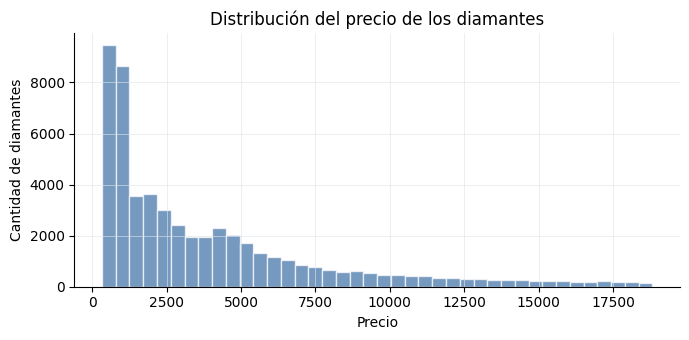

In [ ]:
diamonds = sns.load_dataset("diamonds")

print("Tamaño del dataset:", diamonds.shape)
print("\nTipos de datos:")
print(diamonds.dtypes)

media_precio = diamonds["price"].mean()
mediana_precio = diamonds["price"].median()

print("\nMedia del precio:", media_precio)
print("Mediana del precio:", mediana_precio)

fig, ax = plt.subplots(figsize=(7, 3.5))

ax.hist(
    diamonds["price"],
    bins=40,
    color=AZUL,
    alpha=0.7,
    edgecolor="white"
)

ax.set_xlabel("Precio")
ax.set_ylabel("Cantidad de diamantes")
ax.set_title("Distribución del precio de los diamantes")
eje_limpio(ax)
plt.tight_layout()
plt.show()

# La media es mayor que la mediana.
# Esto indica que la distribución tiene una cola hacia la derecha, causada por una cantidad menor de diamantes con precios muy altos.

# Verificación (descomentar):
assert diamonds.shape == (53940, 10)
assert diamonds["price"].median() == 2401.0

### Ejercicio 8 (0.20): OLS a mano

`price ~ carat` con las ecuaciones normales: (a) `Xb` con columna de unos y `np.linalg.solve`. (b) $R^2$ a mano (`r2_precio`). (c) Comparar contra `LinearRegression`.

In [ ]:
from sklearn.linear_model import LinearRegression

x_c = diamonds["carat"].to_numpy(float)
y_p = diamonds["price"].to_numpy(float)

Xb = np.hstack([
    np.ones((len(x_c), 1)),
    x_c[:, None]
])

w_precio = np.linalg.solve(
    Xb.T @ Xb,
    Xb.T @ y_p
)

pred_precio = Xb @ w_precio
resid_precio = y_p - pred_precio
ss_res = (resid_precio ** 2).sum()
ss_tot = ((y_p - y_p.mean()) ** 2).sum()
r2_precio = 1 - ss_res / ss_tot

print("Xb:", w_precio)
print("R^2 a mano:", r2_precio)

modelo_sklearn = LinearRegression().fit(
    x_c[:, None],
    y_p
)

print("\nIntercepto (sklearn):", modelo_sklearn.intercept_)
print("Pendiente (sklearn):", modelo_sklearn.coef_)
print("R^2 de Linear Regression:", modelo_sklearn.score(x_c[:, None], y_p))

# Verificación (descomentar):
assert round(r2_precio, 3) == 0.849

Xb: [-2256.36058005  7756.42561797]
R^2 a mano: 0.8493305264354858

Intercepto de sklearn: -2256.360580045753
Pendiente de sklearn: [7756.42561797]
R^2 de Linear Regression: 0.8493305264354858


/var/folders/z1/0mf1rsys4m7f1qmb7bcwktsr0000gn/T/ipykernel_67277/2131988216.py:16: RuntimeWarning: divide by zero encountered in matmul
  pred_precio = Xb @ w_precio
/var/folders/z1/0mf1rsys4m7f1qmb7bcwktsr0000gn/T/ipykernel_67277/2131988216.py:16: RuntimeWarning: overflow encountered in matmul
  pred_precio = Xb @ w_precio
/var/folders/z1/0mf1rsys4m7f1qmb7bcwktsr0000gn/T/ipykernel_67277/2131988216.py:16: RuntimeWarning: invalid value encountered in matmul
  pred_precio = Xb @ w_precio


### Ejercicio 9 (0.20): los residuos delatan, el log arregla

(a) Graficar residuos vs predicción del modelo del ejercicio 8. (b) Ajustar `log(price) ~ log(carat)` (`r2_log`) y graficar sus residuos. (c) Comparar los dos $R^2$ y las dos nubes.

R2 del modelo original: 0.8493305264354858
R2 del modelo log-log: 0.9329893079520857


/var/folders/z1/0mf1rsys4m7f1qmb7bcwktsr0000gn/T/ipykernel_67277/2987052405.py:15: RuntimeWarning: divide by zero encountered in matmul
  pred_log = Xb_log @ w_log
/var/folders/z1/0mf1rsys4m7f1qmb7bcwktsr0000gn/T/ipykernel_67277/2987052405.py:15: RuntimeWarning: overflow encountered in matmul
  pred_log = Xb_log @ w_log
/var/folders/z1/0mf1rsys4m7f1qmb7bcwktsr0000gn/T/ipykernel_67277/2987052405.py:15: RuntimeWarning: invalid value encountered in matmul
  pred_log = Xb_log @ w_log


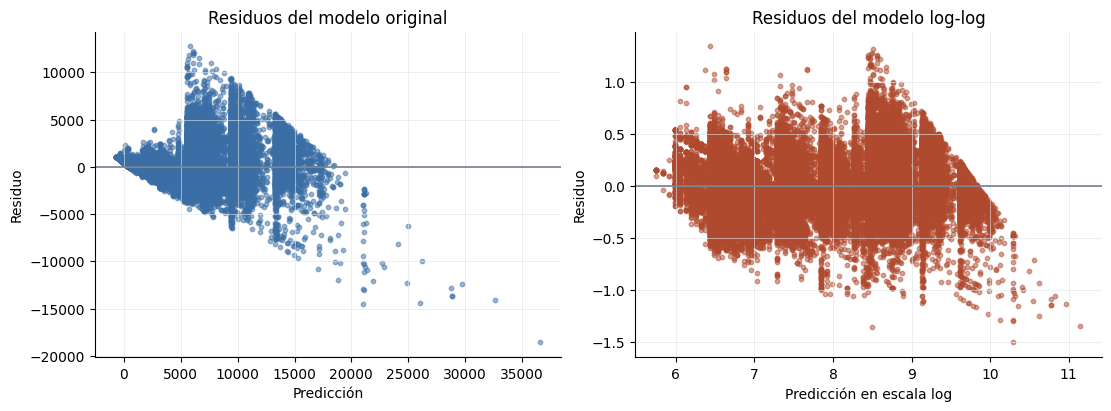

In [21]:
# ¿Qué va aquí?
# Pista: np.log para ambas variables; el patrón del gráfico
# de residuos está en el notebook de la sesión 8.5

x_log = np.log(x_c)
y_log = np.log(y_p)
Xb_log = np.hstack([
    np.ones((len(x_log), 1)),
    x_log[:, None]
])
w_log = np.linalg.solve(
    Xb_log.T @ Xb_log,
    Xb_log.T @ y_log
)
pred_log = Xb_log @ w_log
resid_log = y_log - pred_log
ss_res_log = (resid_log ** 2).sum()
ss_tot_log = ((y_log - y_log.mean()) ** 2).sum()
r2_log = 1 - ss_res_log / ss_tot_log

print("R2 del modelo original:", r2_precio)
print("R2 del modelo log-log:", r2_log)

fig, axes = plt.subplots(
    1, 2,
    figsize=(11, 4),
    layout="constrained"
)

axes[0].scatter(
    pred_precio,
    resid_precio,
    s=10,
    color=AZUL,
    alpha=0.5
)

axes[0].axhline(0, color=GRIS, lw=1.2)
axes[0].set_xlabel("Predicción")
axes[0].set_ylabel("Residuo")
axes[0].set_title("Residuos del modelo original")
axes[1].scatter(
    pred_log,
    resid_log,
    s=10,
    color=ROJO,
    alpha=0.5
)
axes[1].axhline(0, color=GRIS, lw=1.2)
axes[1].set_xlabel("Predicción en escala log")
axes[1].set_ylabel("Residuo")
axes[1].set_title("Residuos del modelo log-log")

for ax in axes:
    eje_limpio(ax)

plt.show()

# El modelo original presenta un patrón más marcado en sus residuos.
# Con los logaritmos, los residuos forman una nube más pareja alrededor de cero y el R2 aumenta de aprox 0.849 a 0.933.

# Verificación (descomentar):
assert round(r2_log, 3) == 0.933

### Ejercicio 10 (0.20): ¿y si agregamos más features?

Regresión múltiple en la escala log: `log(price) ~ log(carat) + depth + table`. Calcular `r2_multi` y responder en un comentario: ¿cuánto mejoró respecto al ejercicio 9?

In [24]:
# ¿Qué va aquí?

X_multi = np.hstack([
    np.log(x_c)[:, None],
    diamonds[["depth", "table"]].to_numpy(float)
])

Xb_multi = np.hstack([
    np.ones((len(X_multi), 1)),
    X_multi
])

w_multi = np.linalg.solve(
    Xb_multi.T @ Xb_multi,
    Xb_multi.T @ y_log
)

pred_multi = Xb_multi @ w_multi
resid_multi = y_log - pred_multi
ss_res_multi = (resid_multi ** 2).sum()
ss_tot_multi = ((y_log - y_log.mean()) ** 2).sum()
r2_multi = 1 - ss_res_multi / ss_tot_multi
mejora = r2_multi - r2_log

print("R2 log-log:", r2_log)
print("R2 multi:", r2_multi)
print("Mejora:", mejora)

# El R2 aumentó aproximadamente de 0.933 a 0.935.
# La mejora fue cercana a 0.002, por lo que depth y table agregaron, poca información adicional al modelo que ya utilizaba log(carat).

# Verificación (descomentar):
assert round(r2_multi, 3) == 0.935

R2 log-log: 0.9329893079520857
R2 multi: 0.9352584483430645
Mejora: 0.0022691403909788077


/var/folders/z1/0mf1rsys4m7f1qmb7bcwktsr0000gn/T/ipykernel_67277/806678066.py:18: RuntimeWarning: divide by zero encountered in matmul
  pred_multi = Xb_multi @ w_multi
/var/folders/z1/0mf1rsys4m7f1qmb7bcwktsr0000gn/T/ipykernel_67277/806678066.py:18: RuntimeWarning: overflow encountered in matmul
  pred_multi = Xb_multi @ w_multi
/var/folders/z1/0mf1rsys4m7f1qmb7bcwktsr0000gn/T/ipykernel_67277/806678066.py:18: RuntimeWarning: invalid value encountered in matmul
  pred_multi = Xb_multi @ w_multi


## Parte D · Criterio (0.2 pt)

### Ejercicio 11 (0.20)

Dos preguntas, 2-3 líneas cada una, **citando los números obtenidos**:

**(a)** El ejercicio 2 dio p = 0.008: el efecto del botón es estadísticamente real. El lift observado fue de medio punto porcentual (10.4% vs 9.9%). ¿Basta eso para lanzar el botón a producción? ¿Qué información falta para decidir?

**(b)** El modelo log-log del ejercicio 9 se ajustó con diamantes de hasta 5 quilates. ¿Por qué no es confiable usarlo para tasar un diamante de 8 quilates, aunque la fórmula produzca un número?

_(Responder editando esta celda)_

**Respuesta (a):** No basta con eso, pues aunque el p-value de 0.008 dice que la diferencia probablemente no es por azar, el aumento fue de solo 0.506, pasando de 9.9% a 10.4%. Antes de lanzarlo faltaría conocer el ingreso adicional, el costo de implementarlo y si afecta negativamente otras métricas.

**Respuesta (b):** A pesar de que el modelo log-log obtuvo un R^2 de aproximadamente 0.933, fue entrenado con diamantes de hasta 5 quilates. Un diamante de 8 quilates está fuera de ese rango, por lo que el modelo estaría adivinando o sacando de contexto y no sabemos si la misma relación continúa en diamantes tan grandes.

## Mini-bitácora de AI (opcional, no penaliza)

Si se usó AI para entender algún concepto, anotar aquí qué se preguntó y qué se entendió. Si no se usó, escribir "No se usó".

- Usé AI para comparar el código con los notebooks de clase y verificar las gráficas y los "assert". En el ejercicio 6 me ayudó a corregir un error, ya que había declarado al revés el orden de spam y normal, haciendo que "np.argsort" ordenara incorrectamente y fallara el "assert". Para el resto del trabajo me guié principalmente con los notebooks y presentaciones compartidos en clase.
